# Fourier Minimal Explanation Pipeline - Self-Contained Notebook

This notebook refactors the explanation pipeline to learn **minimal soft masks in polar Fourier space** instead of wavelet, pixel, or square-grid Fourier masks.

**Pipeline:**
1. Load a YAML config
2. Build FFT/IFFT utilities and a shared-mask autoencoder
3. Train the explainer with fidelity + robustness + soft polar minimality losses
4. Visualize polar frequency masks and reconstructed explanations
5. Compute evaluation metrics (sparsity, label preservation, confidence delta)

**Key idea:** We transform images into Fourier coefficients, group coefficients by radius and angle, and train a shared soft mask that keeps only the minimal polar frequency regions needed to preserve the classifier decision.


## Cell 1 — Imports

In [1]:
import os
import yaml
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as tvm
import torchvision.transforms as T
from torch.utils.data import DataLoader, Subset, Dataset
from PIL import Image
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


Device: cuda


## Cell 2 - Load Config

Point `CONFIG_PATH` at your YAML config and set data inputs as before.

Fourier-specific controls in this notebook:
- `FFT_RADIAL_BINS`, `FFT_ANGULAR_BINS`: number of polar frequency bins
- `mask_temperature`: sigmoid temperature for the soft mask
- `mask_threshold`: threshold used only for reporting hard active-bin ratios
- `lambda_bins`: weight for minimal soft active-bin objective

Input modes are unchanged (single image, image list, or dataset mode).


In [2]:
CONFIG_PATH = "/home/arin_weling/wavex/wavelet_explanation/configs/resnet18_imagenet_fourier_minimal.yaml"
DATA_PATH = "../wavelet_explanation/data"

# Optional direct path override when data is already downloaded.
# path = "/home/arin_weling/wavex/imagenet_mini/val"
# print("Path to dataset files:", path)

# Option 1: train on exactly one image path (ignores DATA_PATH and IMAGE_NAME_LIST).
SINGLE_IMAGE_PATH = None

# Option 2: train on all image names listed here.
# IMAGE_NAME_LIST = [
#     "banded_gecko.jpg",
#     "hound.jpg",
#     "cobra.jpg",
#     "dog.png",
#     "cat.jpg",
#     "husky.jpg",
#     "peacock.jpg",
#     "pitbull.png",
#     "rock_python.jpg",
#     "shih_tzu.jpg",
# ]
IMAGE_NAME_LIST = [
    "peacock.jpg",
]

# If True and IMAGE_NAME_LIST is used, retrain explainer from scratch per image.
RETRAIN_FROM_SCRATCH_PER_IMAGE = True

# If False, only final explanation + graphs are saved.
SAVE_INTERMEDIATE_EXPLANATIONS = False

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f)

# Polar Fourier soft-mask defaults.
config.setdefault("fft_radial_bins", 16)
config.setdefault("fft_angular_bins", 16)
config.setdefault("mask_temperature", 1.0)
config.setdefault("mask_threshold", 0.5)
config.setdefault("lambda_bins", 20.0)
config.setdefault("lambda_energy", 5.0)
config.setdefault("lambda_entropy", 0.0)

# Make training-loop snapshots optional.
if not SAVE_INTERMEDIATE_EXPLANATIONS:
    config["viz_every"] = int(1e9)

print("Config loaded:")
for k, v in config.items():
    print(f"  {k}: {v}")


def _safe_tag(value):
    base = os.path.splitext(os.path.basename(str(value)))[0]
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in base)
    cleaned = cleaned.strip("_")
    return cleaned or "run"


run_tag = None
if SINGLE_IMAGE_PATH:
    run_tag = _safe_tag(SINGLE_IMAGE_PATH)
elif isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0:
    first_name = str(IMAGE_NAME_LIST[0]).strip()
    run_tag = _safe_tag(first_name)
    if len(IMAGE_NAME_LIST) > 1:
        run_tag = f"{run_tag}_plus{len(IMAGE_NAME_LIST) - 1}"

CONFIG_NAME = os.path.splitext(os.path.basename(CONFIG_PATH))[0]
BASE_OUTPUT_DIR = f"my_exp_cam/outputs/{CONFIG_NAME}_polar_soft"
OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, run_tag) if run_tag else BASE_OUTPUT_DIR

import shutil
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
    print(f"Deleted old output directory: {OUTPUT_DIR}")

os.makedirs(OUTPUT_DIR, exist_ok=True)
config_save_path = f"{OUTPUT_DIR}/config.yaml"
shutil.copy(CONFIG_PATH, config_save_path)
print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"Config saved to: {config_save_path}")
print(f"Retrain from scratch per image: {RETRAIN_FROM_SCRATCH_PER_IMAGE}")
print(f"Save intermediate explanations: {SAVE_INTERMEDIATE_EXPLANATIONS}")
print(f"Polar FFT bins: radial={config['fft_radial_bins']}, angular={config['fft_angular_bins']}")
print(f"mask_temperature: {config['mask_temperature']}")
print(f"mask_threshold: {config['mask_threshold']}")
print(f"lambda_bins: {config['lambda_bins']}")
print(f"lambda_energy: {config['lambda_energy']}")
print(f"lambda_entropy: {config['lambda_entropy']}")


Config loaded:
  backbone: resnet18
  pretrained: True
  dataset: imagenet
  image_size: 224
  single_image_mode: True
  single_image_index: 0
  fixed_class_label: None
  filter_class: None
  batch_size: 4
  lr: 1e-06
  epochs: 300
  viz_every: 1000000000
  fft_radial_bins: 16
  fft_angular_bins: 16
  mask_temperature: 0.25
  mask_threshold: 0.5
  lambda_act: 1.0
  lambda_CE: 4.0
  lambda_KL: 0.4
  lambda_rob: 6.0
  lambda_entropy: 0.3
  lambda_bins: 15.0
  lambda_energy: 1500.0
  ins_del_steps: 25
  metrics_curve_max_samples: 4
Deleted old output directory: my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock

Output directory: my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock
Config saved to: my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock/config.yaml
Retrain from scratch per image: True
Save intermediate explanations: False
Polar FFT bins: radial=16, angular=16
mask_temperature: 0.25
mask_threshold: 0.5
lambda_bins: 15

## Cell 3 - Fourier Transform + Polar Frequency Binning

Uses `torch.fft` for autograd-compatible 2D FFT. Coefficients are grouped into polar bins by radius and orientation. Each polar bin receives one shared **soft** mask value.

This gives a direct minimality objective: minimize average soft mask activity while preserving classifier behavior.


In [3]:
FFT_RADIAL_BINS = int(config.get("fft_radial_bins", 16))
FFT_ANGULAR_BINS = int(config.get("fft_angular_bins", 16))
MASK_THRESHOLD = float(config.get("mask_threshold", 0.5))


class FourierPolarMasker(nn.Module):
    '''Utility module for one-sided real FFT transform, inverse transform, and polar mask expansion.'''

    def __init__(self, radial_bins=16, angular_bins=16):
        super().__init__()
        self.radial_bins = int(radial_bins)
        self.angular_bins = int(angular_bins)
        self._index_cache = {}

    def fft2(self, x):
        return torch.fft.rfft2(x, dim=(-2, -1), norm="ortho")

    def ifft2_real(self, coeff, signal_hw):
        h, w = int(signal_hw[-2]), int(signal_hw[-1])
        return torch.fft.irfft2(coeff, s=(h, w), dim=(-2, -1), norm="ortho")

    def _polar_indices(self, height, width, device):
        height = int(height)
        width = int(width)
        key = (height, width, str(device))
        if key in self._index_cache:
            return self._index_cache[key]

        coeff_w = width // 2 + 1
        fy = torch.fft.fftfreq(height, d=1.0, device=device).view(height, 1)
        fx = torch.fft.rfftfreq(width, d=1.0, device=device).view(1, coeff_w)

        radius = torch.sqrt(fx.square() + fy.square())
        radius = radius / radius.max().clamp(min=1e-8)
        radial_idx = torch.clamp((radius * self.radial_bins).long(), max=self.radial_bins - 1)

        # In one-sided RFFT, fx >= 0, so angles live in [-pi/2, pi/2].
        angle = torch.atan2(fy, fx.clamp(min=1e-12))
        angle_norm = ((angle + (torch.pi / 2.0)) / torch.pi).clamp(0.0, 1.0 - 1e-7)
        angular_idx = torch.clamp((angle_norm * self.angular_bins).long(), max=self.angular_bins - 1)

        flat_idx = (radial_idx * self.angular_bins + angular_idx).view(1, 1, -1)
        self._index_cache[key] = flat_idx
        return flat_idx

    def expand_polar_mask(self, m_polar, height, width):
        # m_polar: (B, 1, radial_bins, angular_bins) -> (B, 1, H, W//2+1)
        b = m_polar.shape[0]
        height = int(height)
        width = int(width)
        coeff_w = width // 2 + 1
        flat_mask = m_polar.reshape(b, 1, self.radial_bins * self.angular_bins)
        flat_idx = self._polar_indices(height, width, m_polar.device).expand(b, 1, -1)
        return flat_mask.gather(dim=2, index=flat_idx).view(b, 1, height, coeff_w)

    def harden_mask(self, m_soft, threshold=None):
        threshold = MASK_THRESHOLD if threshold is None else float(threshold)
        return (m_soft >= threshold).float()

    def one_sided_to_full(self, tensor_one_sided, width=None):
        '''Mirror one-sided RFFT layout to full width; conjugate mirror if complex.'''
        w_half = int(tensor_one_sided.shape[-1])
        if width is None:
            width = 2 * (w_half - 1)
        width = int(width)

        if width % 2 == 0:
            core = tensor_one_sided[..., 1:w_half - 1]
        else:
            core = tensor_one_sided[..., 1:w_half]

        core = torch.flip(core, dims=[-1])
        if torch.is_complex(tensor_one_sided):
            core = torch.conj(core)
        return torch.cat([tensor_one_sided, core], dim=-1)

    def one_sided_mask_to_full(self, mask_one_sided, width):
        return self.one_sided_to_full(mask_one_sided, width=width)

    def fft_magnitude_for_viz(self, coeff, width):
        coeff_full = self.one_sided_to_full(coeff, width=width)
        coeff_shift = torch.fft.fftshift(coeff_full, dim=(-2, -1))
        mag = torch.log1p(coeff_shift.abs())
        mag = mag.mean(dim=1, keepdim=True)
        return mag


fourier = FourierPolarMasker(FFT_RADIAL_BINS, FFT_ANGULAR_BINS).to(DEVICE)
print(
    "Fourier utilities ready (one-sided RFFT): "
    f"polar bins=(radial={FFT_RADIAL_BINS}, angular={FFT_ANGULAR_BINS})"
)


Fourier utilities ready (one-sided RFFT): polar bins=(radial=16, angular=16)


## Cell 4 - Shared Soft Polar Fourier Mask Autoencoder

Encoder-decoder network that outputs a **single shared soft polar mask** for Fourier coefficients.

Architecture idea: image -> latent -> mask logits -> adaptive pooling to `(fft_radial_bins, fft_angular_bins)` -> temperature-scaled sigmoid.

This shared soft mask is then expanded to coefficient resolution by polar radius/orientation lookup and applied to all channels.


In [4]:
def _conv_block(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm2d(out_ch, affine=True),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        nn.InstanceNorm2d(out_ch, affine=True),
        nn.ReLU(inplace=True),
    )


class _EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = _conv_block(in_ch, out_ch)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        features = self.conv(x)
        return self.pool(features), features


class _DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
        return self.conv(torch.cat([x, skip], dim=1))


class FourierMaskNet(nn.Module):
    '''Shared-mask autoencoder that outputs one soft polar Fourier mask per sample.'''

    def __init__(self, in_channels=3, radial_bins=16, angular_bins=16, temperature=1.0):
        super().__init__()
        self.radial_bins = int(radial_bins)
        self.angular_bins = int(angular_bins)
        self.temperature = float(temperature)

        self.enc1 = _EncoderBlock(in_channels, 32)
        self.enc2 = _EncoderBlock(32, 64)
        self.enc3 = _EncoderBlock(64, 128)
        self.enc4 = _EncoderBlock(128, 256)
        self.bottleneck = _conv_block(256, 256)
        self.dec4 = _DecoderBlock(256, 256, 128)
        self.dec3 = _DecoderBlock(128, 128, 64)
        self.dec2 = _DecoderBlock(64, 64, 32)
        self.dec1 = _DecoderBlock(32, 32, 32)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.polar_proj = nn.Linear(32, radial_bins * angular_bins)

    def forward(self, x):
        p1, s1 = self.enc1(x)
        p2, s2 = self.enc2(p1)
        p3, s3 = self.enc3(p2)
        p4, s4 = self.enc4(p3)
        b = self.bottleneck(p4)
        d4 = self.dec4(b, s4)
        d3 = self.dec3(d4, s3)
        d2 = self.dec2(d3, s2)
        d1 = self.dec1(d2, s1)

        b_sz = x.shape[0]
        pooled = self.global_pool(d1).view(b_sz, -1)
        m_logits_polar = self.polar_proj(pooled).view(b_sz, 1, self.radial_bins, self.angular_bins)
        temperature = max(self.temperature, 1e-6)
        m_soft_polar = torch.sigmoid(m_logits_polar / temperature)
        return m_soft_polar


in_channels = 1 if config.get("dataset") == "mnist" else 3
MASK_TEMPERATURE = float(config.get("mask_temperature", 1.0))
unet = FourierMaskNet(
    in_channels=in_channels,
    radial_bins=FFT_RADIAL_BINS,
    angular_bins=FFT_ANGULAR_BINS,
    temperature=MASK_TEMPERATURE,
).to(DEVICE)
n_params = sum(p.numel() for p in unet.parameters() if p.requires_grad)
print(f"Soft polar Fourier explainer ready: {n_params:,} trainable parameters")


Soft polar Fourier explainer ready: 3,334,864 trainable parameters


## Cell 5 — Frozen Classifier + Activation Hooks

The classifier is frozen (`requires_grad=False`, **not** `torch.no_grad()`) so gradients still flow *through* it from the loss back to the explanation and then to the U-Net.

Forward hooks on Conv2d, Linear, and ReLU layers capture intermediate activations for the activation matching loss (L_act).

In [5]:
# ── Frozen Classifier ──────────────────────────────────────────────────────

_BACKBONE_REGISTRY = {
    "resnet18":          (tvm.resnet18,          tvm.ResNet18_Weights.DEFAULT),
    "mobilenet_v3_small":(tvm.mobilenet_v3_small, tvm.MobileNet_V3_Small_Weights.DEFAULT),
    "convnext_small":    (tvm.convnext_small,     tvm.ConvNeXt_Small_Weights.DEFAULT),
    "efficientnet_b0":   (tvm.efficientnet_b0,    tvm.EfficientNet_B0_Weights.DEFAULT),
    "vit_b_16":          (tvm.vit_b_16,           tvm.ViT_B_16_Weights.DEFAULT),
}

backbone_name = config.get("backbone", "resnet18")
pretrained = config.get("pretrained", True)

model_fn, weights = _BACKBONE_REGISTRY[backbone_name]
classifier = model_fn(weights=weights if pretrained else None).to(DEVICE)

for param in classifier.parameters():
    param.requires_grad = False
classifier.eval()

print(f"Frozen classifier: {backbone_name} (pretrained={pretrained})")


# ── Activation Hook Manager ───────────────────────────────────────────────

class ActivationHookManager:
    """Captures intermediate activations from Conv2d, Linear, ReLU layers."""

    def __init__(self, model):
        self._hooks = []
        self._activations = {}
        for name, module in model.named_modules():
            if isinstance(module, (nn.Conv2d, nn.Linear, nn.ReLU)):
                ltype = "linear" if isinstance(module, nn.Linear) else (
                    "conv" if isinstance(module, nn.Conv2d) else "relu")
                hook = module.register_forward_hook(self._make_hook(name, ltype))
                self._hooks.append(hook)

    def _make_hook(self, name, layer_type):
        def hook(module, inp, output):
            self._activations[name] = (output, layer_type)
        return hook

    def get_activations(self):
        return dict(self._activations)

    def clear(self):
        self._activations = {}

    def remove(self):
        for h in self._hooks:
            h.remove()
        self._hooks = []

hook_manager = ActivationHookManager(classifier)
print(f"Activation hooks registered on {len(hook_manager._hooks)} layers.")

Frozen classifier: resnet18 (pretrained=True)
Activation hooks registered on 30 layers.


## Cell 6 - Losses + Fourier Explanation Utilities

Kept losses:
- **L_act** activation matching
- **L_CE** target class preservation
- **L_KL** output distribution alignment
- **L_rob** robustness under frequency perturbations
- **L_energy** explanation Fourier-energy minimization on softly kept coefficients
- **L_entropy** optional entropy penalty that pushes soft mask values away from gray 0.5 values

Changed losses:
- Removed smoothness losses (mask TV and explanation TV)
- Removed hard-mask prior
- Replaced hard active-bin count with **soft polar activity loss** `L_bins`
- Added optional soft-mask entropy loss controlled by `lambda_entropy`


In [6]:
_RESNET18_GROUP_WEIGHTS = [
    ("layer4", 8),
    ("layer3", 6),
    ("layer2", 4),
    ("layer1", 2),
]  # stem (conv1/bn1/relu) gets weight 1


def _resnet18_layer_weight(name):
    for prefix, w in _RESNET18_GROUP_WEIGHTS:
        if name.startswith(prefix):
            return w
    return 1


def activation_matching_loss(activations_x, activations_e):
    """Weighted activation matching; ResNet-18 group weights: stem=1, l1=2, l2=4, l3=6, l4=8."""
    common = sorted(set(activations_x) & set(activations_e))
    total = torch.tensor(0.0, device=DEVICE)
    for name in common:
        act_x, ltype = activations_x[name]
        act_e, _ = activations_e[name]
        if ltype == "linear":
            dist = (1.0 - F.cosine_similarity(act_x.detach(), act_e, dim=1)).mean()
        else:
            dist = F.mse_loss(act_e, act_x.detach())
        total = total + _resnet18_layer_weight(name) * dist
    return total

def cross_entropy_loss(logits_e, y):
    return F.cross_entropy(logits_e, y)


def kl_divergence_loss(logits_x, logits_e):
    top_idx = logits_x.detach().argmax(dim=1, keepdim=True)
    p_fake = torch.zeros_like(logits_e).scatter_(1, top_idx, 1.0)
    log_q = F.log_softmax(logits_e, dim=1)
    return F.kl_div(log_q, p_fake, reduction="batchmean")


def soft_bin_activity_loss(m_soft_polar):
    return m_soft_polar.mean()


def mask_entropy_loss(m_soft_polar, eps=1e-6):
    m = m_soft_polar.clamp(eps, 1.0 - eps)
    entropy = -(m * torch.log(m) + (1.0 - m) * torch.log(1.0 - m))
    return entropy.mean()


def explanation_fourier_energy_loss(x, m_soft_polar):
    """Penalize normalized energy in softly kept one-sided Fourier coefficients."""
    coeff = fourier.fft2(x)
    half_mask = fourier.expand_polar_mask(m_soft_polar, x.shape[-2], x.shape[-1])
    explanation_coeff = half_mask * coeff

    explanation_energy = (explanation_coeff.abs() ** 2).sum(dim=(1, 2, 3))
    total_energy = (coeff.abs() ** 2).sum(dim=(1, 2, 3)).clamp(min=1e-8)
    return (explanation_energy / total_energy).mean()


def construct_explanation(x, m_soft_polar):
    coeff = fourier.fft2(x)
    half_mask = fourier.expand_polar_mask(m_soft_polar, x.shape[-2], x.shape[-1])
    e_coeff = coeff * half_mask
    e = fourier.ifft2_real(e_coeff, signal_hw=x.shape[-2:])
    return e


def perturb_explanation(x, m_soft_polar, noise_scale=0.1):
    coeff = fourier.fft2(x)
    half_mask = fourier.expand_polar_mask(m_soft_polar, x.shape[-2], x.shape[-1])
    coeff_std = coeff.abs().std().detach().clamp(min=1e-6)
    noise_real = torch.randn_like(coeff.real) * (noise_scale * coeff_std)
    noise_imag = torch.randn_like(coeff.imag) * (noise_scale * coeff_std)
    noise = torch.complex(noise_real, noise_imag)
    coeff_pert = half_mask * coeff + (1.0 - half_mask) * noise
    return fourier.ifft2_real(coeff_pert, signal_hw=x.shape[-2:])


def to_numpy(t):
    """(C, H, W) tensor -> displayable numpy array."""
    t = t.detach().cpu().float()
    if t.ndim == 3 and t.shape[0] == 3:
        return np.clip(t.permute(1, 2, 0).numpy(), 0, 1)
    if t.ndim == 3 and t.shape[0] == 1:
        return np.clip(t.squeeze(0).numpy(), 0, 1)
    return np.clip(t.numpy(), 0, 1)


print("Fourier losses and explanation utilities ready (soft polar mask training).")


Fourier losses and explanation utilities ready (soft polar mask training).


## Cell 7 — Load Data

Supports four modes:
- **Single image** — set `SINGLE_IMAGE_PATH` above to overfit on one image
- **Image-name list** — set `IMAGE_NAME_LIST` (array of filenames; files are loaded from `DATA_PATH`)
- **Dataset from config** — ImageNet, MNIST, STL-10, or any ImageFolder layout
- **Single image from dataset** — set `single_image_mode: true` in the YAML config

In [7]:
image_size = config.get("image_size", 224)
dataset_name = config.get("dataset", "imagenet")
batch_size = config.get("batch_size", 8)


def _build_transform():
    if dataset_name == "mnist":
        return T.Compose([T.Resize(image_size), T.ToTensor(), T.Normalize((0.1307,), (0.3081,))])
    resize_ops = [] if image_size == 64 else [T.Resize(int(image_size * 1.14)), T.CenterCrop(image_size)]
    return T.Compose([
        *resize_ops,
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])


transform = _build_transform()


def _has_class_subdirs(root):
    if not os.path.isdir(root):
        return False
    return any(os.path.isdir(os.path.join(root, d)) for d in os.listdir(root))


def _resolve_imagefolder_root(root):
    """Support both standard roots and roots containing a train/ subfolder."""
    direct_root = root
    train_root = os.path.join(root, "train")
    if _has_class_subdirs(direct_root):
        return direct_root
    if _has_class_subdirs(train_root):
        return train_root
    return train_root


downloaded_path = globals().get("path", None)
DATA_ROOT = DATA_PATH
if isinstance(downloaded_path, str) and os.path.isdir(downloaded_path):
    DATA_ROOT = downloaded_path
    print(f"Using provided downloaded path as data root: {DATA_ROOT}")

use_standard_folder_loader = (
    isinstance(downloaded_path, str)
    and os.path.isdir(downloaded_path)
    and (_has_class_subdirs(downloaded_path) or _has_class_subdirs(os.path.join(downloaded_path, "train")))
)
if use_standard_folder_loader:
    print("Detected standard class-folder structure in provided path; using dataset loader.")

effective_single_image_mode = bool(config.get("single_image_mode", False))
if use_standard_folder_loader and effective_single_image_mode:
    print("Overriding config single_image_mode=True to process the full folder dataset.")
    effective_single_image_mode = False


class ImageNameListDataset(Dataset):
    """Loads images by filename from DATA_ROOT and assigns pseudo-labels via the frozen classifier."""

    def __init__(self, image_name_list, data_root, transform_fn, in_ch):
        if not isinstance(image_name_list, (list, tuple)):
            raise ValueError("IMAGE_NAME_LIST must be a list/tuple of image filenames.")

        self.transform_fn = transform_fn
        self.image_mode = "RGB" if in_ch == 3 else "L"
        self.image_names = [str(name).strip() for name in image_name_list if str(name).strip()]

        if len(self.image_names) == 0:
            raise ValueError("IMAGE_NAME_LIST is empty.")

        self.paths = []
        for name in self.image_names:
            p = os.path.join(data_root, name)
            if not os.path.isfile(p):
                raise FileNotFoundError(f"Image not found under data root: {p}")
            self.paths.append(p)

        self.image_stems = [os.path.splitext(os.path.basename(p))[0] for p in self.paths]

        # Build pseudo-labels once so train_step can keep using CE/KL/robustness targets.
        self.labels = []
        classifier.eval()
        with torch.no_grad():
            for p in self.paths:
                img = Image.open(p).convert(self.image_mode)
                x = self.transform_fn(img).unsqueeze(0).to(DEVICE)
                y = classifier(x).argmax(dim=1).item()
                self.labels.append(int(y))

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert(self.image_mode)
        x = self.transform_fn(img)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


# -- Mode selection ------------------------------------------------------------
single_image_mode = False
dataloader = None
selected_image_tag = None


if isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not use_standard_folder_loader):
    # Image-name-list mode: each image is loaded from DATA_ROOT/image_name.
    dataset = ImageNameListDataset(IMAGE_NAME_LIST, DATA_ROOT, transform, in_channels)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
    selected_image_tag = dataset.image_stems[0]
    print(
        f"Image-name-list mode: {len(dataset)} images from data root={DATA_ROOT} "
        f"| batch_size={batch_size}"
    )

elif SINGLE_IMAGE_PATH:
    # Single image mode.
    img = Image.open(SINGLE_IMAGE_PATH).convert("RGB" if in_channels == 3 else "L")
    fixed_x = transform(img).unsqueeze(0).to(DEVICE)
    fixed_class = config.get("fixed_class_label", None)
    fixed_class = None if fixed_class is None or str(fixed_class).lower() == "none" else fixed_class
    if fixed_class is not None:
        fixed_y = torch.tensor([int(fixed_class)], dtype=torch.long, device=DEVICE)
    else:
        with torch.no_grad():
            fixed_y = classifier(fixed_x).argmax(dim=1)
    single_image_mode = True
    selected_image_tag = os.path.splitext(os.path.basename(SINGLE_IMAGE_PATH))[0]
    print(f"Single image mode: {SINGLE_IMAGE_PATH} | target class: {fixed_y.item()}")

else:
    # Dataset mode from config.
    if dataset_name == "imagenet":
        # If a downloaded path is provided, prefer ImageFolder semantics for class-folder layout.
        if DATA_ROOT != DATA_PATH:
            imagefolder_root = _resolve_imagefolder_root(DATA_ROOT)
            dataset = torchvision.datasets.ImageFolder(root=imagefolder_root, transform=transform)
            print(
                "Dataset loader override: using ImageFolder for provided path "
                f"(root={imagefolder_root})."
            )
            dataset_name = "imagefolder"
        else:
            dataset = torchvision.datasets.ImageNet(root=DATA_ROOT, split="train", transform=transform)
    elif dataset_name == "imagefolder":
        imagefolder_root = _resolve_imagefolder_root(DATA_ROOT)
        dataset = torchvision.datasets.ImageFolder(root=imagefolder_root, transform=transform)
        print(f"ImageFolder root: {imagefolder_root}")
    elif dataset_name == "mnist":
        dataset = torchvision.datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
    elif dataset_name == "stl10":
        dataset = torchvision.datasets.STL10(root=DATA_ROOT, split="train", download=True, transform=transform)
    else:
        raise ValueError(f"Unsupported dataset: {dataset_name}")

    # Optional class filter.
    filter_class = config.get("filter_class", None)
    if filter_class is not None:
        labels = np.array(dataset.labels if hasattr(dataset, "labels") else dataset.targets)
        dataset = Subset(dataset, np.where(labels == int(filter_class))[0].tolist())

    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

    # Check for single-image-from-dataset mode.
    if effective_single_image_mode:
        idx = config.get("single_image_index", 0)
        img_tensor, _ = dataset[idx]
        fixed_x = img_tensor.unsqueeze(0).to(DEVICE)
        fc = config.get("fixed_class_label", None)
        fc = None if fc is None or str(fc).lower() == "none" else fc
        if fc is not None:
            fixed_y = torch.tensor([int(fc)], dtype=torch.long, device=DEVICE)
        else:
            with torch.no_grad():
                fixed_y = classifier(img_tensor.unsqueeze(0).to(DEVICE)).argmax(dim=1)
        single_image_mode = True
        selected_image_tag = f"dataset_idx_{idx}"
        print(f"Single image mode (from dataset index {idx}): target class {fixed_y.item()}")
    else:
        selected_image_tag = dataset_name
        print(f"Dataset: {dataset_name} | {len(dataloader.dataset)} examples | batch_size={batch_size}")


# Ensure output folder includes image tag when available.
def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


if selected_image_tag:
    desired_output_dir = os.path.join(BASE_OUTPUT_DIR, _safe_output_tag(selected_image_tag))
else:
    desired_output_dir = BASE_OUTPUT_DIR

if OUTPUT_DIR != desired_output_dir:
    OUTPUT_DIR = desired_output_dir
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# Keep a config copy inside the active save directory.
config_save_path = f"{OUTPUT_DIR}/config.yaml"
shutil.copy(CONFIG_PATH, config_save_path)
print(f"Active output directory: {OUTPUT_DIR}")

Image-name-list mode: 1 images from data root=../wavelet_explanation/data | batch_size=4
Active output directory: my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock


## Cell 8 - Training Step

One gradient update that:
1. Autoencoder predicts a shared soft polar Fourier mask
2. Build explanation `e = IFFT(m * FFT(x))`
3. Forward `x` and `e` through the frozen classifier and capture activations
4. Optimize fidelity + robustness + minimal soft-mask objectives


In [8]:
lambda_act = config.get("lambda_act", 1.0)
lambda_CE = config.get("lambda_CE", 4.0)
lambda_KL = config.get("lambda_KL", 0.4)
lambda_rob = config.get("lambda_rob", 6.0)
lambda_bins = config.get("lambda_bins", 20.0)
lambda_energy = config.get("lambda_energy", 5.0)
lambda_entropy = config.get("lambda_entropy", 0.0)

learning_rate = config.get("lr", 1e-4)


def _build_explainer_model():
    return FourierMaskNet(
        in_channels=in_channels,
        radial_bins=FFT_RADIAL_BINS,
        angular_bins=FFT_ANGULAR_BINS,
        temperature=MASK_TEMPERATURE,
    ).to(DEVICE)


def reset_explainer_and_optimizer():
    """Reinitialize explainer weights and optimizer state."""
    global unet, optimizer
    unet = _build_explainer_model()
    optimizer = torch.optim.Adam(unet.parameters(), lr=learning_rate)
    return unet, optimizer


optimizer = torch.optim.Adam(unet.parameters(), lr=learning_rate)
fixed_class_label = config.get("fixed_class_label", None)


def train_step(x, y):
    """Single gradient update. Returns dict of weighted loss values."""
    unet.train()

    # 1) Predict shared soft polar Fourier masks
    m_soft_polar = unet(x)

    # 2) Construct explanation via hard-masked Fourier coefficients (straight-through estimator)
    m_hard_ste = fourier.harden_mask(m_soft_polar) + (m_soft_polar - m_soft_polar.detach())
    e = construct_explanation(x, m_hard_ste)

    # 3) Forward x and e through classifier
    hook_manager.clear()
    logits_x = classifier(x)
    activations_x = hook_manager.get_activations()

    hook_manager.clear()
    logits_e = classifier(e)
    activations_e = hook_manager.get_activations()

    # 4) Losses
    l_act = activation_matching_loss(activations_x, activations_e)

    if fixed_class_label is not None:
        y_target = torch.full((x.shape[0],), int(fixed_class_label), dtype=torch.long, device=x.device)
    else:
        y_target = logits_x.argmax(dim=1).detach()

    l_ce = cross_entropy_loss(logits_e, y_target)
    l_kl = kl_divergence_loss(logits_x, logits_e)

    e_pert = perturb_explanation(x, m_soft_polar)
    hook_manager.clear()
    logits_pert = classifier(e_pert)
    l_rob = F.cross_entropy(logits_pert, y_target)

    l_bins = soft_bin_activity_loss(m_soft_polar)
    l_energy = explanation_fourier_energy_loss(x, m_soft_polar)
    l_entropy = mask_entropy_loss(m_soft_polar)

    probs_e = torch.softmax(logits_e.detach(), dim=1)
    target_conf = probs_e.gather(1, y_target.unsqueeze(1)).mean()
    pred_conf = probs_e.max(dim=1).values.mean()
    m_hard_polar = fourier.harden_mask(m_soft_polar.detach())

    l_exp = (
        lambda_act * l_act
        + lambda_CE * l_ce
        + lambda_KL * l_kl
        + lambda_rob * l_rob
        + lambda_bins * l_bins
        + lambda_energy * l_energy
        + lambda_entropy * l_entropy
    )

    optimizer.zero_grad()
    l_exp.backward()
    nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
    optimizer.step()

    return {
        "total": l_exp.item(),
        "act": (lambda_act * l_act).item(),
        "ce": (lambda_CE * l_ce).item(),
        "kl": (lambda_KL * l_kl).item(),
        "rob": (lambda_rob * l_rob).item(),
        "bins": (lambda_bins * l_bins).item(),
        "energy": (lambda_energy * l_energy).item(),
        "entropy": (lambda_entropy * l_entropy).item(),
        "mask_entropy": float(l_entropy.detach().item()),
        "soft_mask_mean": float(m_soft_polar.detach().mean().item()),
        "active_bins_ratio": float(m_hard_polar.mean().item()),
        "target_confidence": float(target_conf.item()),
        "pred_confidence": float(pred_conf.item()),
    }


print("train_step() defined for soft polar Fourier minimal explanations.")


train_step() defined for soft polar Fourier minimal explanations.


## Cell 9 — Training Loop

Runs epochs over the selected input mode. Supports optional per-image retraining when `IMAGE_NAME_LIST` and `RETRAIN_FROM_SCRATCH_PER_IMAGE` are enabled.

In [9]:
epochs = int(config.get("epochs", 50))
viz_every = int(config.get("viz_every", 1))
if viz_every < 1:
    raise ValueError(f"viz_every must be >= 1, got {viz_every}")

loss_history = []
latest_best_snapshot = None
per_image_loss_history = {}


def _denorm_for_snapshot(tensor):
    t = tensor.clone().cpu()
    if dataset_name in ("imagenet", "imagefolder", "stl10"):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        t = t * std + mean
    elif dataset_name == "mnist":
        t = t * 0.3081 + 0.1307
    return t.clamp(0, 1)


def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


def _capture_visual_snapshot(viz_sample_x_local):
    with torch.no_grad():
        unet.eval()
        m_soft_polar_v = unet(viz_sample_x_local)
        e_v = construct_explanation(viz_sample_x_local, m_soft_polar_v)
        logits_e_v = classifier(e_v)
        probs_e_v = torch.softmax(logits_e_v, dim=1)
        top_conf_v, top_class_v = probs_e_v[0].max(dim=0)

        coeff_x = fourier.fft2(viz_sample_x_local)
        half_mask = fourier.expand_polar_mask(m_soft_polar_v, viz_sample_x_local.shape[-2], viz_sample_x_local.shape[-1])
        coeff_e = coeff_x * half_mask
        fft_mag_before = fourier.fft_magnitude_for_viz(coeff_x, width=viz_sample_x_local.shape[-1]).detach().cpu()
        fft_mag_after = fourier.fft_magnitude_for_viz(coeff_e, width=viz_sample_x_local.shape[-1]).detach().cpu()

    return {
        "epoch": None,
        "loss_total": None,
        "m_soft_polar": m_soft_polar_v.detach().cpu(),
        "m_hard_polar": fourier.harden_mask(m_soft_polar_v).detach().cpu(),
        "sample_x": viz_sample_x_local.detach().cpu(),
        "x_denorm": _denorm_for_snapshot(viz_sample_x_local),
        "e_denorm": _denorm_for_snapshot(e_v),
        "fft_mag_before": fft_mag_before,
        "fft_mag_after": fft_mag_after,
        "top_class": int(top_class_v.item()),
        "top_conf": float(top_conf_v.item()),
    }


def _run_training_for_fixed_sample(fixed_x_local, fixed_y_local, local_epochs):
    local_history = []
    window_best = None
    window_start_epoch = 1
    global latest_best_snapshot

    for epoch in range(1, local_epochs + 1):
        losses = train_step(fixed_x_local, fixed_y_local)
        local_history.append(losses)

        non_loss_keys = {"soft_mask_mean", "active_bins_ratio", "target_confidence", "pred_confidence"}
        loss_str = "  ".join(f"{k}={v:.4f}" for k, v in losses.items() if k not in non_loss_keys)
        print(
            f"Epoch {epoch:3d}/{local_epochs}  {loss_str}  "
            f"soft_mask_mean={losses['soft_mask_mean']:.4f}  "
            f"active_bins_ratio={losses['active_bins_ratio']:.4f}  "
            f"target_confidence={losses['target_confidence']:.4f}  "
            f"pred_confidence={losses['pred_confidence']:.4f}"
        )

        total_loss = float(losses.get("total", sum(v for k, v in losses.items() if k not in non_loss_keys)))
        if window_best is None or total_loss < window_best["loss_total"]:
            snap = _capture_visual_snapshot(fixed_x_local[:1])
            snap["epoch"] = epoch
            snap["loss_total"] = total_loss
            window_best = snap

        window_end = (epoch % viz_every == 0) or (epoch == local_epochs)
        if window_end and window_best is not None:
            latest_best_snapshot = window_best
            print(
                f"  -> Window best [{window_start_epoch}, {epoch}] at epoch {window_best['epoch']} "
                f"with total={window_best['loss_total']:.4f}"
            )
            window_start_epoch = epoch + 1
            window_best = None

    return local_history


image_list_mode = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

if retrain_per_image:
    print("Image-list mode with retrain-from-scratch per image is ON.")

    if "dataset" not in globals():
        raise RuntimeError("Expected image-list dataset to be initialized in Cell 7.")

    for img_idx in range(len(dataset)):
        image_name = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
        image_stem = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
        x_img, y_img = dataset[img_idx]
        y_label = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)

        image_folder_tag = _safe_output_tag(f"{image_stem}_cls{y_label}")
        OUTPUT_DIR = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        shutil.copy(CONFIG_PATH, f"{OUTPUT_DIR}/config.yaml")

        reset_explainer_and_optimizer()
        print(f"\n=== Training from scratch for image {img_idx + 1}/{len(dataset)}: {image_name} ===")

        fixed_x_img = x_img.unsqueeze(0).to(DEVICE)
        if fixed_class_label is not None:
            fixed_y_img = torch.tensor([int(fixed_class_label)], dtype=torch.long, device=DEVICE)
        else:
            fixed_y_img = torch.tensor([y_label], dtype=torch.long, device=DEVICE)

        local_loss_history = _run_training_for_fixed_sample(fixed_x_img, fixed_y_img, epochs)
        per_image_loss_history[image_folder_tag] = local_loss_history
        loss_history = local_loss_history

        ckpt_path = os.path.join(OUTPUT_DIR, "fourier_masknet_checkpoint.pth")
        torch.save(
            {
                "encoder_decoder_state_dict": unet.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config,
            },
            ckpt_path,
        )
        print(f"Checkpoint saved to {ckpt_path}")

    print("Training complete (per-image retrain mode).")

else:
    if single_image_mode:
        fixed_x_local = fixed_x
        fixed_y_local = fixed_y
        loss_history = _run_training_for_fixed_sample(fixed_x_local, fixed_y_local, epochs)
    else:
        # Dataset mode: average losses per epoch over batches.
        viz_sample_x, viz_sample_y = next(iter(dataloader))
        viz_sample_x = viz_sample_x[:1].to(DEVICE)
        if fixed_class_label is not None:
            viz_target = torch.tensor([int(fixed_class_label)], dtype=torch.long, device=DEVICE)
        else:
            with torch.no_grad():
                viz_target = classifier(viz_sample_x).argmax(dim=1)

        window_best = None
        window_start_epoch = 1

        for epoch in range(1, epochs + 1):
            accum = {}
            n = 0
            for x_batch, y_batch in tqdm(dataloader, desc=f"Epoch {epoch}", leave=False):
                x_batch = x_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)
                batch_losses = train_step(x_batch, y_batch)
                for k, v in batch_losses.items():
                    accum[k] = accum.get(k, 0.0) + v
                n += 1

            losses = {k: v / n for k, v in accum.items()}
            loss_history.append(losses)

            non_loss_keys = {"soft_mask_mean", "active_bins_ratio", "target_confidence", "pred_confidence"}
            loss_str = "  ".join(f"{k}={v:.4f}" for k, v in losses.items() if k not in non_loss_keys)
            print(
                f"Epoch {epoch:3d}/{epochs}  {loss_str}  "
                f"soft_mask_mean={losses['soft_mask_mean']:.4f}  "
                f"active_bins_ratio={losses['active_bins_ratio']:.4f}  "
                f"target_confidence={losses['target_confidence']:.4f}  "
                f"pred_confidence={losses['pred_confidence']:.4f}"
            )

            total_loss = float(losses.get("total", sum(v for k, v in losses.items() if k not in non_loss_keys)))
            if window_best is None or total_loss < window_best["loss_total"]:
                snap = _capture_visual_snapshot(viz_sample_x)
                snap["epoch"] = epoch
                snap["loss_total"] = total_loss
                window_best = snap

            window_end = (epoch % viz_every == 0) or (epoch == epochs)
            if window_end and window_best is not None:
                latest_best_snapshot = window_best
                print(
                    f"  -> Window best [{window_start_epoch}, {epoch}] at epoch {window_best['epoch']} "
                    f"with total={window_best['loss_total']:.4f}"
                )
                window_start_epoch = epoch + 1
                window_best = None

    ckpt_path = os.path.join(OUTPUT_DIR, "fourier_masknet_checkpoint.pth")
    torch.save(
        {
            "encoder_decoder_state_dict": unet.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "config": config,
        },
        ckpt_path,
    )
    print(f"Checkpoint saved to {ckpt_path}")
    print("Training complete.")

Image-list mode with retrain-from-scratch per image is ON.

=== Training from scratch for image 1/1: peacock.jpg ===
Epoch   1/300  total=350.7528  act=32.2479  ce=5.8976  kl=0.5898  rob=0.0500  bins=7.1867  energy=304.6025  entropy=0.1785  mask_entropy=0.5949  soft_mask_mean=0.4791  active_bins_ratio=0.4805  target_confidence=0.2289  pred_confidence=0.2419
Epoch   2/300  total=350.5704  act=32.2479  ce=5.8976  kl=0.5898  rob=0.0216  bins=7.1865  energy=304.4486  entropy=0.1785  mask_entropy=0.5949  soft_mask_mean=0.4791  active_bins_ratio=0.4805  target_confidence=0.2289  pred_confidence=0.2419
Epoch   3/300  total=350.4183  act=32.2479  ce=5.8976  kl=0.5898  rob=0.0236  bins=7.1864  energy=304.2946  entropy=0.1785  mask_entropy=0.5949  soft_mask_mean=0.4791  active_bins_ratio=0.4805  target_confidence=0.2289  pred_confidence=0.2419
Epoch   4/300  total=350.2676  act=32.2479  ce=5.8976  kl=0.5898  rob=0.0277  bins=7.1863  energy=304.1400  entropy=0.1785  mask_entropy=0.5949  soft_mask

## Cell 10 — Loss Curves

Plot the training loss history to check convergence.

Saved loss curves to my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock_cls84/loss_curves.png


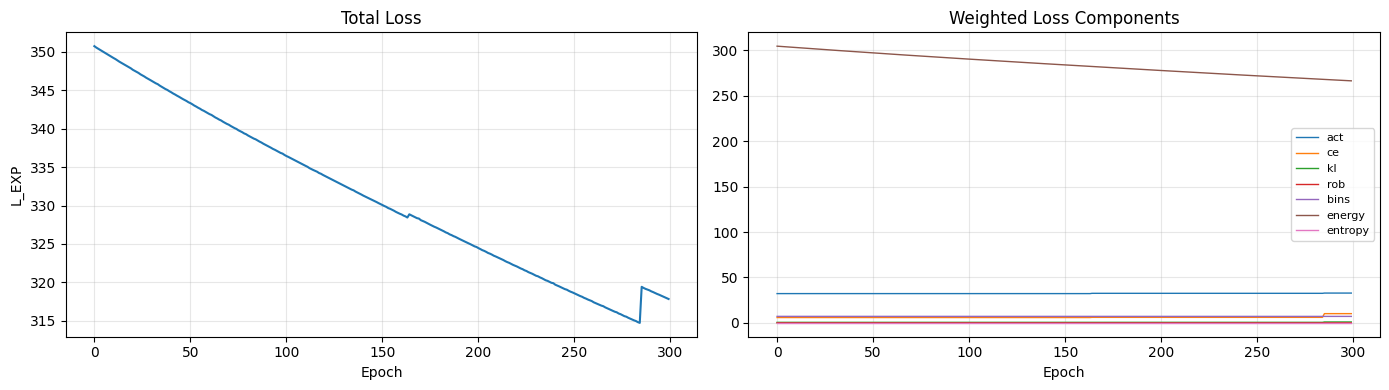

Saved active-bin ratio curve to my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock_cls84/active_bins_ratio_curve.png


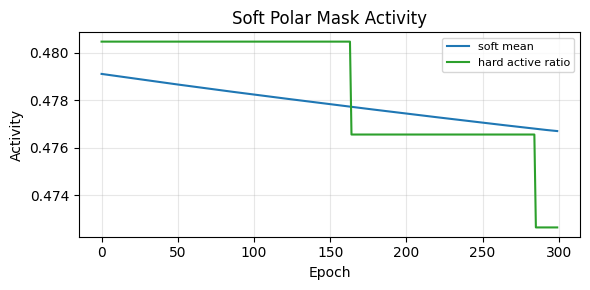

In [10]:
if len(loss_history) == 0:
    raise RuntimeError("loss_history is empty. Run training first.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot([h["total"] for h in loss_history], linewidth=1.5)
axes[0].set_title("Total Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("L_EXP")
axes[0].grid(True, alpha=0.3)

for key in ["act", "ce", "kl", "rob", "bins", "energy", "entropy"]:
    axes[1].plot([h.get(key, np.nan) for h in loss_history], label=key, linewidth=1)
axes[1].set_title("Weighted Loss Components")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/loss_curves.png", dpi=100, bbox_inches="tight")
print(f"Saved loss curves to {OUTPUT_DIR}/loss_curves.png")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(6, 3))
ax.plot([h.get("soft_mask_mean", np.nan) for h in loss_history], linewidth=1.5, color="#1f77b4", label="soft mean")
ax.plot([h.get("active_bins_ratio", np.nan) for h in loss_history], linewidth=1.5, color="#2ca02c", label="hard active ratio")
ax.set_title("Soft Polar Mask Activity")
ax.set_xlabel("Epoch")
ax.set_ylabel("Activity")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/active_bins_ratio_curve.png", dpi=100, bbox_inches="tight")
print(f"Saved active-bin ratio curve to {OUTPUT_DIR}/active_bins_ratio_curve.png")
plt.show()

## Cell 11 - Visualize Soft Polar Fourier Explanation

Visualizes:
- Original image
- Shared soft polar mask
- Hard thresholded polar mask for reporting
- FFT log-magnitude before and after masking
- Reconstructed explanation image

In per-image retrain mode, saves one final visualization per image folder.


In [11]:
def denorm(tensor):
    """Reverse normalization for display."""
    t = tensor.clone().cpu()
    if dataset_name in ("imagenet", "imagefolder", "stl10"):
        mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)
        t = t * std + mean
    elif dataset_name == "mnist":
        t = t * 0.3081 + 0.1307
    return t.clamp(0, 1)


def to_numpy(t):
    t = t.detach().cpu().float()
    if t.ndim == 3 and t.shape[0] == 3:
        return np.clip(t.permute(1, 2, 0).numpy(), 0, 1)
    if t.ndim == 3 and t.shape[0] == 1:
        return np.clip(t.squeeze(0).numpy(), 0, 1)
    return np.clip(t.numpy(), 0, 1)


def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


def _run_visual_inference(sample_x):
    with torch.no_grad():
        unet.eval()
        m_soft_polar = unet(sample_x)
        e = construct_explanation(sample_x, m_soft_polar)
        logits_e = classifier(e)
        probs_viz = torch.softmax(logits_e, dim=1)
        top_conf_tensor, top_class_tensor = probs_viz[0].max(dim=0)

        coeff_x = fourier.fft2(sample_x)
        half_mask = fourier.expand_polar_mask(m_soft_polar, sample_x.shape[-2], sample_x.shape[-1])
        coeff_e = coeff_x * half_mask
        fft_mag_before = fourier.fft_magnitude_for_viz(coeff_x, width=sample_x.shape[-1])
        fft_mag_after = fourier.fft_magnitude_for_viz(coeff_e, width=sample_x.shape[-1])

    return {
        "m_soft_polar": m_soft_polar,
        "m_hard_polar": fourier.harden_mask(m_soft_polar),
        "e": e,
        "x_disp": denorm(sample_x),
        "e_disp": denorm(e),
        "fft_mag_before": fft_mag_before,
        "fft_mag_after": fft_mag_after,
        "top_class": int(top_class_tensor.item()),
        "top_conf": float(top_conf_tensor.item()),
    }


def _save_fourier_explanation_figure(result, save_path, title_suffix=""):
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))
    fig.suptitle(f"Soft Polar Fourier Explanation {title_suffix}".strip(), fontsize=12, fontweight="bold")

    axes[0][0].imshow(to_numpy(result["x_disp"][0]))
    axes[0][0].set_title("Original")
    axes[0][0].axis("off")

    axes[0][1].imshow(to_numpy(result["m_soft_polar"][0]), cmap="magma", vmin=0, vmax=1)
    axes[0][1].set_title("Soft Polar Mask")
    axes[0][1].axis("off")

    axes[0][2].imshow(to_numpy(result["e_disp"][0]))
    axes[0][2].set_title("Reconstructed Explanation")
    axes[0][2].axis("off")

    axes[1][0].imshow(to_numpy(result["fft_mag_before"][0]), cmap="inferno")
    axes[1][0].set_title("FFT log-mag (original)")
    axes[1][0].axis("off")

    axes[1][1].imshow(to_numpy(result["fft_mag_after"][0]), cmap="inferno")
    axes[1][1].set_title("FFT log-mag (masked)")
    axes[1][1].axis("off")

    axes[1][2].axis("off")
    axes[1][2].text(
        0.02,
        0.95,
        f"Pred class: {result['top_class']}\nConf: {result['top_conf']:.4f}",
        va="top",
        fontsize=11,
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.close()


image_list_mode = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

if image_list_mode and retrain_per_image and ("dataset" in globals()):
    print("Saving one final Fourier explanation per processed image...")
    saved_paths = []

    for img_idx in range(len(dataset)):
        image_name = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
        image_stem = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
        x_img, y_img = dataset[img_idx]
        y_label = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)
        image_folder_tag = _safe_output_tag(f"{image_stem}_cls{y_label}")
        image_output_dir = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
        os.makedirs(image_output_dir, exist_ok=True)

        ckpt_path = os.path.join(image_output_dir, "fourier_masknet_checkpoint.pth")
        if not os.path.isfile(ckpt_path):
            print(f"Skipping {image_name}: checkpoint not found at {ckpt_path}")
            continue

        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        unet.load_state_dict(ckpt["encoder_decoder_state_dict"], strict=True)
        unet.eval()

        sample_x = x_img.unsqueeze(0).to(DEVICE)
        result = _run_visual_inference(sample_x)
        save_path = f"{image_output_dir}/fourier_explanation_final_cls{result['top_class']}_conf{result['top_conf']:.4f}.png"
        _save_fourier_explanation_figure(result, save_path)
        saved_paths.append(save_path)
        print(f"Saved explanation to {save_path}")

    if len(saved_paths) == 0:
        print("No per-image final explanations were saved.")
    else:
        print(f"Saved {len(saved_paths)} per-image final explanations.")

else:
    if "latest_best_snapshot" in globals() and latest_best_snapshot is not None:
        result = {
            "m_soft_polar": latest_best_snapshot["m_soft_polar"],
            "m_hard_polar": latest_best_snapshot["m_hard_polar"],
            "x_disp": latest_best_snapshot["x_denorm"],
            "e_disp": latest_best_snapshot["e_denorm"],
            "fft_mag_before": latest_best_snapshot["fft_mag_before"],
            "fft_mag_after": latest_best_snapshot["fft_mag_after"],
            "top_class": latest_best_snapshot["top_class"],
            "top_conf": latest_best_snapshot["top_conf"],
        }
    else:
        if single_image_mode:
            sample_x = fixed_x
        else:
            sample_x, _ = next(iter(dataloader))
            sample_x = sample_x[:1].to(DEVICE)
        result = _run_visual_inference(sample_x)

    save_path = f"{OUTPUT_DIR}/fourier_explanation_final_cls{result['top_class']}_conf{result['top_conf']:.4f}.png"
    _save_fourier_explanation_figure(result, save_path)
    print(f"Saved explanation to {save_path}")

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(to_numpy(result["e_disp"][0]))
    ax.set_title("Final Explanation Preview")
    ax.axis("off")
    plt.tight_layout()
    plt.show()

Saving one final Fourier explanation per processed image...
Saved explanation to my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock_cls84/fourier_explanation_final_cls84_conf0.9963.png
Saved 1 per-image final explanations.


## Cell 12 - Polar Frequency Attribution Map

Shows where the model keeps frequency information:
- Soft polar mask
- Hard thresholded polar mask
- Expanded soft mask in full Fourier resolution
- Masked FFT magnitude


Saved frequency-bin attribution to my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock_cls84/frequency_bin_attribution.png


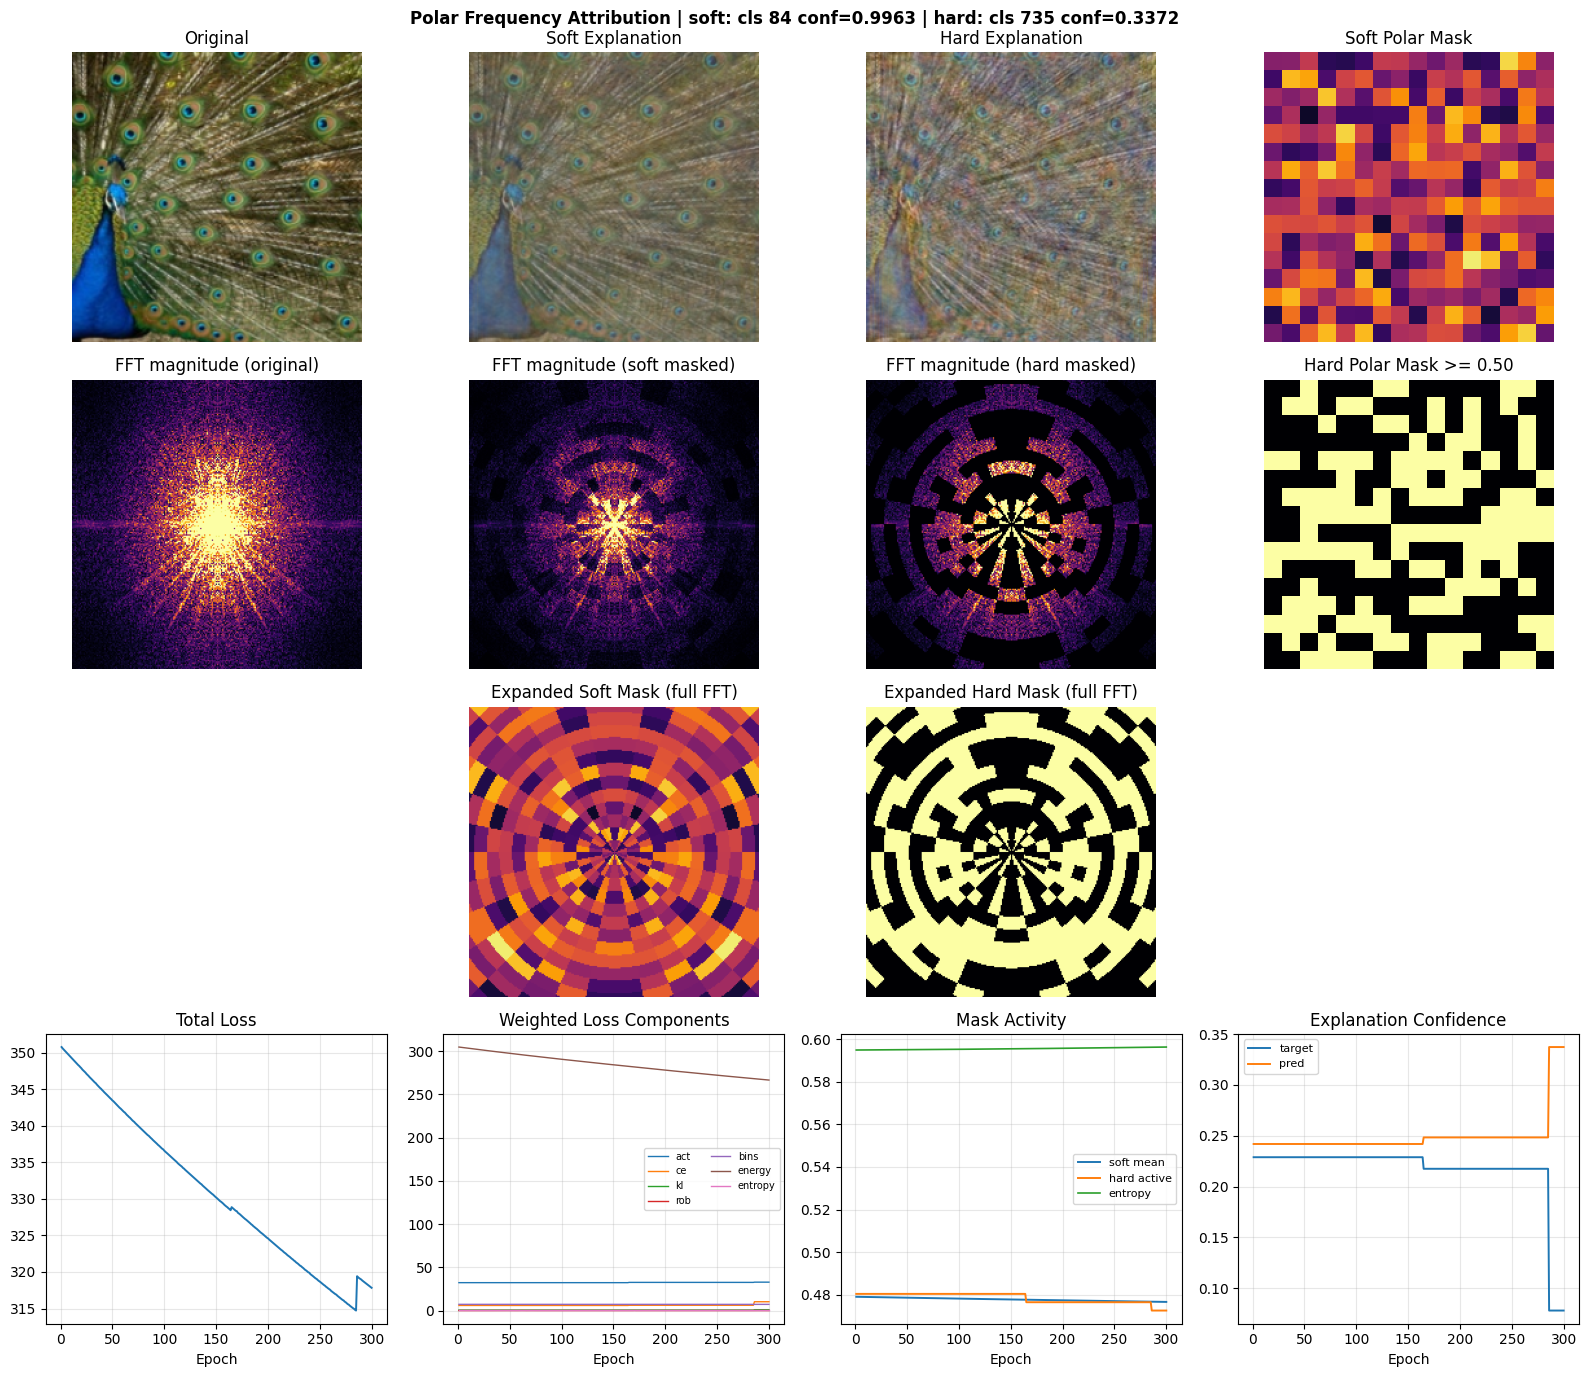

In [12]:
if "latest_best_snapshot" in globals() and latest_best_snapshot is not None:
    m_soft_polar_viz = latest_best_snapshot["m_soft_polar"].to(DEVICE)
    sample_x_viz = latest_best_snapshot["sample_x"].to(DEVICE)
else:
    if single_image_mode:
        sample_x_viz = fixed_x[:1]
    else:
        sample_x_viz, _ = next(iter(dataloader))
        sample_x_viz = sample_x_viz[:1].to(DEVICE)
    with torch.no_grad():
        m_soft_polar_viz = unet(sample_x_viz)

with torch.no_grad():
    m_hard_polar_viz = fourier.harden_mask(m_soft_polar_viz)
    coeff_x = fourier.fft2(sample_x_viz)

    # soft mask explanation
    half_mask_soft = fourier.expand_polar_mask(m_soft_polar_viz, sample_x_viz.shape[-2], sample_x_viz.shape[-1])
    coeff_e_soft = coeff_x * half_mask_soft
    e_soft_viz = fourier.ifft2_real(coeff_e_soft, signal_hw=sample_x_viz.shape[-2:])
    probs_soft = torch.softmax(classifier(e_soft_viz), dim=1)
    soft_conf, soft_class = probs_soft[0].max(dim=0)

    # hard mask explanation
    half_mask_hard = fourier.expand_polar_mask(m_hard_polar_viz, sample_x_viz.shape[-2], sample_x_viz.shape[-1])
    coeff_e_hard = coeff_x * half_mask_hard
    e_hard_viz = fourier.ifft2_real(coeff_e_hard, signal_hw=sample_x_viz.shape[-2:])
    probs_hard = torch.softmax(classifier(e_hard_viz), dim=1)
    hard_conf, hard_class = probs_hard[0].max(dim=0)

    x_disp_local = denorm(sample_x_viz)
    e_soft_disp = denorm(e_soft_viz)
    e_hard_disp = denorm(e_hard_viz)
    mask_full_soft = torch.fft.fftshift(fourier.one_sided_mask_to_full(half_mask_soft, width=sample_x_viz.shape[-1]), dim=(-2, -1))
    mask_full_hard = torch.fft.fftshift(fourier.one_sided_mask_to_full(half_mask_hard, width=sample_x_viz.shape[-1]), dim=(-2, -1))
    def _fft_mag(coeff, width):
        full = fourier.one_sided_to_full(coeff, width=width)
        shifted = torch.fft.fftshift(full, dim=(-2, -1))
        mag = shifted.abs().mean(dim=1, keepdim=True)
        return mag

    fft_mag_orig = _fft_mag(coeff_x, sample_x_viz.shape[-1])
    fft_mag_soft = _fft_mag(coeff_e_soft, sample_x_viz.shape[-1])
    fft_mag_hard = _fft_mag(coeff_e_hard, sample_x_viz.shape[-1])

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
fig.suptitle(
    f"Polar Frequency Attribution | "
    f"soft: cls {int(soft_class.item())} conf={float(soft_conf.item()):.4f} | "
    f"hard: cls {int(hard_class.item())} conf={float(hard_conf.item()):.4f}",
    fontsize=12,
    fontweight="bold",
)

# Row 0: original + soft explanation + polar masks
axes[0][0].imshow(to_numpy(x_disp_local[0]))
axes[0][0].set_title("Original")
axes[0][0].axis("off")

axes[0][1].imshow(to_numpy(e_soft_disp[0]))
axes[0][1].set_title("Soft Explanation")
axes[0][1].axis("off")

axes[0][3].imshow(to_numpy(m_soft_polar_viz[0]), cmap="inferno", vmin=0, vmax=1)
axes[0][3].set_title("Soft Polar Mask")
axes[0][3].axis("off")

axes[1][3].imshow(to_numpy(m_hard_polar_viz[0]), cmap="inferno", vmin=0, vmax=1)
axes[1][3].set_title(f"Hard Polar Mask >= {MASK_THRESHOLD:.2f}")
axes[1][3].axis("off")

# Row 1: soft mask in Fourier space + FFT comparisons
axes[2][1].imshow(to_numpy(mask_full_soft[0]), cmap="inferno", vmin=0, vmax=1)
axes[2][1].set_title("Expanded Soft Mask (full FFT)")
axes[2][1].axis("off")

axes[1][0].imshow(to_numpy(fft_mag_orig[0]), cmap="inferno", vmin=0, vmax=1)
axes[1][0].set_title("FFT magnitude (original)")
axes[1][0].axis("off")

axes[1][1].imshow(to_numpy(fft_mag_soft[0]), cmap="inferno", vmin=0, vmax=1)
axes[1][1].set_title("FFT magnitude (soft masked)")
axes[1][1].axis("off")

axes[1][3].axis("off")
axes[2][0].axis("off")
axes[0][3].axis("off")

# Row 2: hard mask explanation
axes[0][2].imshow(to_numpy(e_hard_disp[0]))
axes[0][2].set_title("Hard Explanation")
axes[0][2].axis("off")

axes[2][2].imshow(to_numpy(mask_full_hard[0]), cmap="inferno", vmin=0, vmax=1)
axes[2][2].set_title("Expanded Hard Mask (full FFT)")
axes[2][2].axis("off")

axes[1][2].imshow(to_numpy(fft_mag_hard[0]), cmap="inferno", vmin=0, vmax=1)
axes[1][2].set_title("FFT magnitude (hard masked)")
axes[1][2].axis("off")

axes[2][3].axis("off")

# Row 3: loss plots
if len(loss_history) > 0:
    epochs_axis = np.arange(1, len(loss_history) + 1)

    axes[3][0].plot(epochs_axis, [h.get("total", np.nan) for h in loss_history], linewidth=1.4)
    axes[3][0].set_title("Total Loss")
    axes[3][0].set_xlabel("Epoch")
    axes[3][0].grid(True, alpha=0.3)

    for key in ["act", "ce", "kl", "rob", "bins", "energy", "entropy"]:
        axes[3][1].plot(epochs_axis, [h.get(key, np.nan) for h in loss_history], label=key, linewidth=1.0)
    axes[3][1].set_title("Weighted Loss Components")
    axes[3][1].set_xlabel("Epoch")
    axes[3][1].legend(fontsize=7, ncol=2)
    axes[3][1].grid(True, alpha=0.3)

    axes[3][2].plot(epochs_axis, [h.get("soft_mask_mean", np.nan) for h in loss_history], label="soft mean", linewidth=1.4)
    axes[3][2].plot(epochs_axis, [h.get("active_bins_ratio", np.nan) for h in loss_history], label="hard active", linewidth=1.4)
    axes[3][2].plot(epochs_axis, [h.get("mask_entropy", np.nan) for h in loss_history], label="entropy", linewidth=1.2)
    axes[3][2].set_title("Mask Activity")
    axes[3][2].set_xlabel("Epoch")
    axes[3][2].legend(fontsize=8)
    axes[3][2].grid(True, alpha=0.3)

    axes[3][3].plot(epochs_axis, [h.get("target_confidence", np.nan) for h in loss_history], label="target", linewidth=1.4)
    axes[3][3].plot(epochs_axis, [h.get("pred_confidence", np.nan) for h in loss_history], label="pred", linewidth=1.4)
    axes[3][3].set_title("Explanation Confidence")
    axes[3][3].set_xlabel("Epoch")
    axes[3][3].legend(fontsize=8)
    axes[3][3].grid(True, alpha=0.3)
else:
    for ax in axes[3]:
        ax.axis("off")
    axes[3][0].text(0.02, 0.95, "No loss history available", va="top", fontsize=11)

plt.tight_layout()
save_path = f"{OUTPUT_DIR}/frequency_bin_attribution.png"
plt.savefig(save_path, dpi=120, bbox_inches="tight")
print(f"Saved frequency-bin attribution to {save_path}")
plt.show()

## Cell 13 - Evaluation Metrics (Per-Image + GradCAM + Averages)

For each processed image, this cell compares:
- **Your soft polar Fourier method**
- **GradCAM baseline**

Shared metrics are preserved (label preservation, confidence delta, insertion/deletion AUC).
Fourier-specific metrics include soft mask mean, hard active-bin ratio, and low/mid/high frequency retention fractions.


In [13]:
import json
import math

ins_del_steps = int(config.get("ins_del_steps", 25))
metrics_curve_max_samples = int(config.get("metrics_curve_max_samples", 4))


def _safe_output_tag(name):
    cleaned = "".join(ch if (ch.isalnum() or ch in ("-", "_")) else "_" for ch in str(name))
    cleaned = cleaned.strip("_")
    return cleaned or "run"


def _normalize_mask(mask):
    m = mask.detach().float()
    flat = m.view(m.shape[0], -1)
    m_min = flat.min(dim=1).values.view(-1, 1, 1, 1)
    m_max = flat.max(dim=1).values.view(-1, 1, 1, 1)
    return ((m - m_min) / (m_max - m_min + 1e-8)).clamp(0.0, 1.0)


def _auc01(curve):
    xs = torch.linspace(0.0, 1.0, steps=curve.numel(), device=curve.device, dtype=curve.dtype)
    return float(torch.trapz(curve, xs).item())


def _pixel_ins_del_auc(xi, score_map, class_idx, n_steps=25):
    _, H, W = xi.shape
    total = H * W
    ranked = torch.argsort(score_map.reshape(-1), descending=True)

    base = torch.zeros_like(xi)
    ins_vals, del_vals = [], []

    for step in range(n_steps + 1):
        k = int(round((step / float(n_steps)) * total))
        mask_flat = torch.zeros(total, device=xi.device, dtype=xi.dtype)
        if k > 0:
            mask_flat[ranked[:k]] = 1.0
        mask = mask_flat.view(1, H, W)

        x_ins = base + xi * mask
        x_del = xi * (1.0 - mask)

        with torch.no_grad():
            p_ins = F.softmax(classifier(x_ins.unsqueeze(0)), dim=1)[0, class_idx]
            p_del = F.softmax(classifier(x_del.unsqueeze(0)), dim=1)[0, class_idx]
        ins_vals.append(p_ins)
        del_vals.append(p_del)

    ins_curve = torch.stack(ins_vals)
    del_curve = torch.stack(del_vals)
    return _auc01(ins_curve), _auc01(del_curve)


def _compute_faithfulness_metrics(x, logits_x, pred_x, mask_soft):
    mask_soft = mask_soft.clamp(0.0, 1.0)
    if mask_soft.shape[1] != 1:
        mask_soft = mask_soft.mean(dim=1, keepdim=True)

    with torch.no_grad():
        pred_in = classifier(x * mask_soft).argmax(dim=1)
        logits_masked_out = classifier(x * (1.0 - mask_soft))

    fid_in = float((pred_in == pred_x).float().mean().item())

    fx_c = logits_x.gather(1, pred_x.unsqueeze(1)).squeeze(1)
    fx_masked_out_c = logits_masked_out.gather(1, pred_x.unsqueeze(1)).squeeze(1)
    ff_median = float((fx_c - fx_masked_out_c).median().item())

    n_curve = min(x.shape[0], max(1, metrics_curve_max_samples))
    ins_scores, del_scores = [], []
    for i in range(n_curve):
        ins_auc_i, del_auc_i = _pixel_ins_del_auc(
            x[i],
            mask_soft[i, 0],
            int(pred_x[i].item()),
            n_steps=ins_del_steps,
        )
        ins_scores.append(ins_auc_i)
        del_scores.append(del_auc_i)

    insertion_auc = float(np.mean(ins_scores))
    deletion_auc = float(np.mean(del_scores))

    return {
        "fid_in": fid_in,
        "ff_median": ff_median,
        "insertion_auc": insertion_auc,
        "deletion_auc": deletion_auc,
    }


def _compute_shared_metrics(x, logits_x, logits_e, mask_soft):
    pred_x = logits_x.argmax(dim=1)
    pred_e = logits_e.argmax(dim=1)
    label_pres = float((pred_x == pred_e).float().mean().item())

    prob_x = F.softmax(logits_x, dim=1)
    prob_e = F.softmax(logits_e, dim=1)
    conf_x = prob_x[torch.arange(len(pred_x), device=x.device), pred_x]
    conf_e = prob_e[torch.arange(len(pred_x), device=x.device), pred_x]
    conf_delta = float((conf_e - conf_x).mean().item())

    if mask_soft.shape[1] != 1:
        mask_soft = mask_soft.mean(dim=1, keepdim=True)
    mask_soft = mask_soft.clamp(0.0, 1.0)

    activity = float(mask_soft.mean().item())
    sparsity = float(1.0 - activity)

    faith = _compute_faithfulness_metrics(x, logits_x, pred_x, mask_soft)

    out = {
        "label_preservation": label_pres,
        "confidence_delta": conf_delta,
        "activity": activity,
        "sparsity": sparsity,
        "target_confidence_original": float(conf_x.mean().item()),
        "target_confidence_explanation": float(conf_e.mean().item()),
    }
    out.update(faith)
    return out


def _frequency_band_fractions(mask_full):
    """Compute low/mid/high fractions from centered radius bands."""
    _, _, H, W = mask_full.shape
    yy = torch.arange(H, device=mask_full.device).float() - (H - 1) / 2.0
    xx = torch.arange(W, device=mask_full.device).float() - (W - 1) / 2.0
    Y, X = torch.meshgrid(yy, xx, indexing="ij")
    R = torch.sqrt(X**2 + Y**2)
    Rn = R / (R.max() + 1e-8)

    low = (Rn <= 0.33).float().view(1, 1, H, W)
    mid = ((Rn > 0.33) & (Rn <= 0.66)).float().view(1, 1, H, W)
    high = (Rn > 0.66).float().view(1, 1, H, W)

    # Use fftshifted mask so radius reflects natural frequency distance from center.
    m = torch.fft.fftshift(mask_full, dim=(-2, -1))
    total = m.sum(dim=(2, 3), keepdim=True).clamp(min=1e-8)

    low_frac = (m * low).sum(dim=(2, 3), keepdim=True) / total
    mid_frac = (m * mid).sum(dim=(2, 3), keepdim=True) / total
    high_frac = (m * high).sum(dim=(2, 3), keepdim=True) / total

    return float(low_frac.mean().item()), float(mid_frac.mean().item()), float(high_frac.mean().item())


def _find_last_conv_layer(model):
    for module in reversed(list(model.modules())):
        if isinstance(module, nn.Conv2d):
            return module
    return None


GRADCAM_TARGET_LAYER = _find_last_conv_layer(classifier)
if GRADCAM_TARGET_LAYER is None:
    print("Warning: No Conv2d layer found in classifier; GradCAM metrics will be NaN.")
else:
    print(f"GradCAM target layer: {GRADCAM_TARGET_LAYER.__class__.__name__}")


def _compute_gradcam_mask(x, target_idx):
    if GRADCAM_TARGET_LAYER is None:
        return None

    acts, grads = [], []

    def _fwd_hook(module, inp, output):
        acts.append(output)

    def _bwd_hook(module, grad_input, grad_output):
        grads.append(grad_output[0])

    h_fwd = GRADCAM_TARGET_LAYER.register_forward_hook(_fwd_hook)
    h_bwd = GRADCAM_TARGET_LAYER.register_full_backward_hook(_bwd_hook)

    try:
        x_cam = x.detach().clone().requires_grad_(True)
        classifier.zero_grad(set_to_none=True)
        logits = classifier(x_cam)
        score = logits.gather(1, target_idx.view(-1, 1)).sum()
        score.backward()

        if len(acts) == 0 or len(grads) == 0:
            return None

        a = acts[0]
        g = grads[0]
        weights = g.mean(dim=(2, 3), keepdim=True)
        cam = (weights * a).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=x_cam.shape[-2:], mode="bilinear", align_corners=False)
        cam = _normalize_mask(cam).detach()

        classifier.zero_grad(set_to_none=True)
        return cam
    finally:
        h_fwd.remove()
        h_bwd.remove()


def _evaluate_methods_on_batch(eval_x):
    unet.eval()
    classifier.eval()

    with torch.no_grad():
        logits_x = classifier(eval_x)
        m_soft_polar = unet(eval_x)
        e_method = construct_explanation(eval_x, m_soft_polar)
        logits_method = classifier(e_method)

    method_mask_half = fourier.expand_polar_mask(m_soft_polar, eval_x.shape[-2], eval_x.shape[-1]).detach()
    method_mask_full = fourier.one_sided_mask_to_full(method_mask_half, width=eval_x.shape[-1])
    method_mask = _normalize_mask(method_mask_full)
    method_metrics = _compute_shared_metrics(eval_x, logits_x, logits_method, method_mask)

    m_hard_polar = fourier.harden_mask(m_soft_polar.detach())
    low_f, mid_f, high_f = _frequency_band_fractions(method_mask)
    method_metrics["soft_mask_mean"] = float(m_soft_polar.detach().mean().item())
    method_metrics["active_bins_ratio"] = float(m_hard_polar.mean().item())
    method_metrics["low_freq_fraction"] = low_f
    method_metrics["mid_freq_fraction"] = mid_f
    method_metrics["high_freq_fraction"] = high_f

    pred_x = logits_x.argmax(dim=1).detach()
    cam_mask = _compute_gradcam_mask(eval_x, pred_x)

    if cam_mask is None:
        gradcam_metrics = {
            "label_preservation": float("nan"),
            "confidence_delta": float("nan"),
            "activity": float("nan"),
            "sparsity": float("nan"),
            "target_confidence_original": float("nan"),
            "target_confidence_explanation": float("nan"),
            "fid_in": float("nan"),
            "ff_median": float("nan"),
            "insertion_auc": float("nan"),
            "deletion_auc": float("nan"),
            "soft_mask_mean": float("nan"),
            "active_bins_ratio": float("nan"),
            "low_freq_fraction": float("nan"),
            "mid_freq_fraction": float("nan"),
            "high_freq_fraction": float("nan"),
        }
    else:
        with torch.no_grad():
            gradcam_expl = eval_x * cam_mask
            logits_gradcam = classifier(gradcam_expl)
        gradcam_metrics = _compute_shared_metrics(eval_x, logits_x, logits_gradcam, cam_mask)
        g_low, g_mid, g_high = _frequency_band_fractions(cam_mask)
        gradcam_metrics["soft_mask_mean"] = float("nan")
        gradcam_metrics["active_bins_ratio"] = float("nan")
        gradcam_metrics["low_freq_fraction"] = g_low
        gradcam_metrics["mid_freq_fraction"] = g_mid
        gradcam_metrics["high_freq_fraction"] = g_high

    return method_metrics, gradcam_metrics

def _is_number(x):
    return isinstance(x, (int, float, np.floating)) and math.isfinite(float(x))


def _average_metric_dict(metric_dicts):
    all_keys = sorted(set().union(*[d.keys() for d in metric_dicts])) if metric_dicts else []
    out = {}
    for key in all_keys:
        vals = [float(d[key]) for d in metric_dicts if key in d and _is_number(d[key])]
        if len(vals) > 0:
            out[key] = float(np.mean(vals))
    return out


def _write_json(path, payload):
    with open(path, "w") as f:
        json.dump(payload, f, indent=2)


METRIC_PREFERENCE = {
    "label_preservation": "higher",
    "confidence_delta": "higher",
    "activity": "lower",
    "sparsity": "higher",
    "target_confidence_original": "higher",
    "target_confidence_explanation": "higher",
    "fid_in": "higher",
    "ff_median": "higher",
    "insertion_auc": "higher",
    "deletion_auc": "lower",
    "soft_mask_mean": "lower",
    "active_bins_ratio": "lower",
    "low_freq_fraction": "context",
    "mid_freq_fraction": "context",
    "high_freq_fraction": "context",
}


def _metric_pref_suffix(metric_name):
    better = METRIC_PREFERENCE.get(metric_name, "higher")
    if better == "higher":
        return "higher better"
    if better == "lower":
        return "lower better"
    return "context"


def _metric_label(metric_name):
    return f"{metric_name}\n({_metric_pref_suffix(metric_name)})"


def _plot_method_comparison_bar(method_metrics, gradcam_metrics, title, save_path):
    keys = sorted(set(method_metrics.keys()) | set(gradcam_metrics.keys()))
    keys = [k for k in keys if _is_number(method_metrics.get(k, float("nan"))) or _is_number(gradcam_metrics.get(k, float("nan")))]
    if len(keys) == 0:
        print(f"Skipping bar plot (no numeric metrics): {save_path}")
        return

    method_vals = [float(method_metrics.get(k, float("nan"))) for k in keys]
    gradcam_vals = [float(gradcam_metrics.get(k, float("nan"))) for k in keys]

    x = np.arange(len(keys))
    width = 0.38

    fig, ax = plt.subplots(figsize=(max(12, len(keys) * 0.8), 5))
    ax.bar(x - width / 2, method_vals, width, label="Your Method", color="#1f77b4")
    ax.bar(x + width / 2, gradcam_vals, width, label="GradCAM", color="#ff7f0e")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel("Metric Value")
    ax.set_xticks(x)
    metric_labels = [_metric_label(k) for k in keys]
    ax.set_xticklabels(metric_labels, rotation=45, ha="right", fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"Saved bar chart: {save_path}")


results = []
image_list_mode = isinstance(IMAGE_NAME_LIST, (list, tuple)) and len(IMAGE_NAME_LIST) > 0 and (not single_image_mode)
retrain_per_image = bool(globals().get("RETRAIN_FROM_SCRATCH_PER_IMAGE", False)) and image_list_mode

if image_list_mode:
    print("Evaluating per image (Fourier method vs GradCAM)...")

    if "dataset" not in globals():
        raise RuntimeError("Expected image-list dataset to be initialized in Cell 7.")

    for img_idx in range(len(dataset)):
        image_name = dataset.image_names[img_idx] if hasattr(dataset, "image_names") else f"img_{img_idx}"
        image_stem = dataset.image_stems[img_idx] if hasattr(dataset, "image_stems") else os.path.splitext(os.path.basename(str(image_name)))[0]
        x_img, y_img = dataset[img_idx]
        y_label = int(y_img.item()) if torch.is_tensor(y_img) else int(y_img)
        image_folder_tag = _safe_output_tag(f"{image_stem}_cls{y_label}")
        image_output_dir = os.path.join(BASE_OUTPUT_DIR, image_folder_tag)
        os.makedirs(image_output_dir, exist_ok=True)

        if retrain_per_image:
            ckpt_path = os.path.join(image_output_dir, "fourier_masknet_checkpoint.pth")
            if not os.path.isfile(ckpt_path):
                print(f"Warning: checkpoint missing for {image_name}: {ckpt_path}")
                continue
            ckpt = torch.load(ckpt_path, map_location=DEVICE)
            unet.load_state_dict(ckpt["encoder_decoder_state_dict"], strict=True)

        eval_x = x_img.unsqueeze(0).to(DEVICE)
        method_metrics, gradcam_metrics = _evaluate_methods_on_batch(eval_x)

        per_image_metrics_path = os.path.join(image_output_dir, "metrics_method_vs_gradcam.json")
        record = {
            "image_index": int(img_idx),
            "image_name": str(image_name),
            "output_dir": image_output_dir,
            "method": method_metrics,
            "gradcam": gradcam_metrics,
            "metrics_json_path": per_image_metrics_path,
        }
        results.append(record)

        _write_json(per_image_metrics_path, record)
        print(f"Saved per-image metrics: {per_image_metrics_path}")

        per_image_bar_path = os.path.join(image_output_dir, "metrics_method_vs_gradcam_bar.png")
        _plot_method_comparison_bar(
            method_metrics,
            gradcam_metrics,
            title=f"Method vs GradCAM ({image_stem})",
            save_path=per_image_bar_path,
        )

    if len(results) == 0:
        raise RuntimeError("No per-image metrics were generated.")

    method_avg = _average_metric_dict([r["method"] for r in results])
    gradcam_avg = _average_metric_dict([r["gradcam"] for r in results])

    summary_path = os.path.join(BASE_OUTPUT_DIR, "metrics_method_vs_gradcam_summary.json")
    summary = {
        "num_images": len(results),
        "method_average": method_avg,
        "gradcam_average": gradcam_avg,
        "per_image_results": results,
        "summary_json_path": summary_path,
    }

    _write_json(summary_path, summary)
    print(f"Saved average comparison summary: {summary_path}")

    avg_bar_path = os.path.join(BASE_OUTPUT_DIR, "metrics_method_vs_gradcam_average_bar.png")
    _plot_method_comparison_bar(
        method_avg,
        gradcam_avg,
        title="Average Metrics: Your Soft Polar Fourier Method vs GradCAM",
        save_path=avg_bar_path,
    )

    print("\n" + "=" * 60)
    print("AVERAGE METRICS ACROSS IMAGES")
    print("=" * 60)
    print("\nYour Method:")
    for k, v in method_avg.items():
        print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")
    print("\nGradCAM:")
    for k, v in gradcam_avg.items():
        print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")

else:
    if single_image_mode:
        eval_x = fixed_x
    else:
        eval_x, _ = next(iter(dataloader))
        eval_x = eval_x.to(DEVICE)

    method_metrics, gradcam_metrics = _evaluate_methods_on_batch(eval_x)
    payload = {
        "num_images": int(eval_x.shape[0]),
        "method": method_metrics,
        "gradcam": gradcam_metrics,
    }

    fallback_json_path = os.path.join(OUTPUT_DIR, "metrics_method_vs_gradcam.json")
    _write_json(fallback_json_path, payload)
    print(f"Saved metrics comparison: {fallback_json_path}")

    fallback_bar_path = os.path.join(OUTPUT_DIR, "metrics_method_vs_gradcam_bar.png")
    _plot_method_comparison_bar(
        method_metrics,
        gradcam_metrics,
        title="Method vs GradCAM (Current Batch)",
        save_path=fallback_bar_path,
    )

    print("\n" + "=" * 50)
    print("EVALUATION METRICS (CURRENT BATCH)")
    print("=" * 50)
    print("\nYour Method:")
    for k, v in method_metrics.items():
        if _is_number(v):
            print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")
    print("\nGradCAM:")
    for k, v in gradcam_metrics.items():
        if _is_number(v):
            print(f"  {k:>30s} ({_metric_pref_suffix(k)}): {v:+.6f}")

GradCAM target layer: Conv2d
Evaluating per image (Fourier method vs GradCAM)...
Saved per-image metrics: my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock_cls84/metrics_method_vs_gradcam.json
Saved bar chart: my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/peacock_cls84/metrics_method_vs_gradcam_bar.png
Saved average comparison summary: my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/metrics_method_vs_gradcam_summary.json
Saved bar chart: my_exp_cam/outputs/resnet18_imagenet_fourier_minimal_polar_soft/metrics_method_vs_gradcam_average_bar.png

AVERAGE METRICS ACROSS IMAGES

Your Method:
               active_bins_ratio (lower better): +0.472656
                        activity (lower better): +0.475253
                confidence_delta (higher better): -0.003675
                    deletion_auc (lower better): +0.238867
                       ff_median (higher better): +11.206413
                          fid_in (higher better): +1.

## Cell 14 — Save / Load Checkpoint

Save the trained Fourier mask autoencoder for later reuse. The classifier is frozen and not saved.

In [14]:
# CHECKPOINT_PATH = "fourier_masknet_checkpoint.pth"

# # Save
# torch.save({
#     "encoder_decoder_state_dict": unet.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "config": config,
# }, CHECKPOINT_PATH)
# print(f"Checkpoint saved to {CHECKPOINT_PATH}")

# # To load later:
# # ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
# # unet.load_state_dict(ckpt["encoder_decoder_state_dict"])
# # optimizer.load_state_dict(ckpt["optimizer_state_dict"])